# 08-Custom ML Metric Scraping (Prometheus)

In Lesson 07, we utilized OpenTelemetry and Jaeger to map the exact microsecond bottlenecks of individual inference requests. Distributed tracing is phenomenal for surgical debugging, but it is mathematically inefficient for high-altitude, aggregate system monitoring. You cannot manually read 10,000 trace waterfalls per minute to determine if your GPU cluster is healthy.

To achieve continuous, real-time operational intelligence, we transition from Tracing to **Metrology**. We must instrument our Machine Learning code to expose aggregated mathematical states—such as average token generation speeds, active batch sizes, and input payload distributions.

Instead of pushing heavy, unstructured text logs to a database, we will utilize **Prometheus**, the industry-standard time-series database. Prometheus operates on a **Pull Model**, actively scraping highly compressed mathematical vectors directly from the RAM of our inference containers, ensuring zero performance degradation even under massive LLM workloads.

# 1. The Mathematics of PromQL & Time-Series ML Vectors

### The Time-Series Data Model ($M$)

In Prometheus, a metric is not a text string; it is a strict mathematical time-series vector defined by a metric name, an array of dimensional key-value labels, a microsecond timestamp $t$, and a 64-bit float payload $y$:


$$M = \langle \text{Name}, \{L_1, L_2, \dots, L_n\}, t, y \rangle$$

By applying labels like `model_version="llama3-8b"` or `quantization="int8"`, we construct an $N$-dimensional data matrix that can be instantly sliced and aggregated using the Prometheus Query Language (PromQL).

### The Four ML Metric Primitives

To evaluate ML systems, we utilize specific mathematical structures:

1. **Counters (Monotonically Increasing):** Used for cumulative tracking (e.g., Total Tokens Generated). Counters never decrease. To calculate real-time **Tokens Per Second (TPS)**, we compute the discrete derivative over a rolling temporal window $\Delta t$:

$$\text{rate}(X[t]) = \frac{X_t - X_{t-\Delta t}}{\Delta t}$$


2. **Gauges (Point-in-Time):** Values that arbitrarily rise and fall (e.g., Active GPU Batch Size, VRAM Utilization).
3. **Histograms (Distributions):** Used to calculate quantiles (e.g., $P_{99}$ Latency, Prompt Length Distributions). Histograms group observations into predefined arithmetic "buckets".
4. **Summaries:** Similar to Histograms, but calculate quantiles client-side. (Less common in distributed ML grids due to aggregation limitations).

### Mathematical Isolation of ML Health

If an LLM's latency suddenly doubles, standard API metrics cannot tell you why. By tracking custom ML metrics, we can isolate the root cause mathematically. If $P_{99}(\text{Latency})$ doubles, but $\text{rate}(\text{TokensGenerated})$ remains perfectly stable, the bottleneck is not the GPU; it is the network ingress routing.

# 2. Imperative Execution: Instrumenting the LLM Application

We will use Python's official `prometheus_client` to inject an active metrology registry directly into a simulated LLM inference engine. This script will expose custom Generative AI metrics natively.

In [1]:
# Required installations: pip install prometheus_client numpy
import time
import random
import numpy as np
from prometheus_client import start_http_server, Counter, Gauge, Histogram

print("--- 🚀 Initializing Prometheus ML Metrology Sandbox ---")

# 1. 📝 Define the Custom ML Metric Schemas
# COUNTER: Tracks cumulative tokens to calculate TPS (Tokens Per Second)
TOKENS_GENERATED = Counter(
    'llm_tokens_generated_total', 
    'Total number of output tokens generated', 
    ['model_name']
)

# GAUGE: Tracks the current size of the dynamic batching engine
ACTIVE_BATCH_SIZE = Gauge(
    'llm_active_batch_size', 
    'Current number of requests grouped in the GPU inference batch',
    ['model_name']
)

# HISTOGRAM: Tracks the distribution of input prompt lengths
PROMPT_LENGTH_DIST = Histogram(
    'llm_prompt_length_tokens', 
    'Distribution of input prompt token counts', 
    ['model_name'],
    buckets=[128, 256, 512, 1024, 2048, 4096, 8192] # Standard LLM context bounds
)

def simulate_llm_inference_traffic():
    # Expose the raw mathematical telemetry in a background thread on port 8000
    start_http_server(8000)
    print("   [SYSTEM] Prometheus Metrics Endpoint exposed at http://127.0.0.1:8000/metrics")
    print("   [SYSTEM] Simulating incoming LLM API traffic...")
    
    while True:
        # Simulate an incoming batch of API requests
        current_batch_size = random.randint(1, 32)
        ACTIVE_BATCH_SIZE.labels(model_name='llama-3-8b').set(current_batch_size)
        
        # Simulate varying prompt lengths from users
        for _ in range(current_batch_size):
            prompt_length = int(np.random.lognormal(mean=5.5, sigma=1.0))
            PROMPT_LENGTH_DIST.labels(model_name='llama-3-8b').observe(prompt_length)
        
        # Simulate GPU computation time and token generation
        time.sleep(random.uniform(0.1, 0.5))
        
        # Simulate output tokens generated for this batch
        generated_tokens = current_batch_size * random.randint(10, 50)
        TOKENS_GENERATED.labels(model_name='llama-3-8b').inc(generated_tokens)

# Note: In a live environment, you would execute simulate_llm_inference_traffic()
print("   ✅ Instrumented LLM Application successfully compiled.")
print("   -> Physics: When running, this process maps float vectors to a lightweight HTTP endpoint.")

--- 🚀 Initializing Prometheus ML Metrology Sandbox ---
   ✅ Instrumented LLM Application successfully compiled.
   -> Physics: When running, this process maps float vectors to a lightweight HTTP endpoint.


# 3. Declarative Execution: The Prometheus Scrape Matrix

Prometheus does not passively wait for logs. We must define a declarative YAML configuration that maps the topological coordinates of our ML infrastructure, commanding the Prometheus daemon to actively pull the telemetry vectors.

In [2]:
import os

print("\n--- ⚡ Compiling Declarative Prometheus Scrape Target ---")

obs_sandbox = "./prometheus_sandbox"
os.makedirs(obs_sandbox, exist_ok=True)

# 📝 Define the configuration matrix
prometheus_yaml = """
global:
  scrape_interval: 5s      # Pull data every 5 seconds (High resolution)
  evaluation_interval: 5s

scrape_configs:
  # Target 1: The Custom LLM Inference Engine
  - job_name: 'local_llm_engine'
    metrics_path: '/metrics'
    static_configs:
      - targets: ['host.docker.internal:8000']
        labels:
          environment: 'production'
          hardware: 'gpu-cluster-01'
"""

prom_config_path = os.path.join(obs_sandbox, "prometheus.yml")
with open(prom_config_path, "w") as f:
    f.write(prometheus_yaml.strip())

print(f"   ✅ Prometheus Scrape Matrix Compiled: {prom_config_path}")

print("\n--- 🛠️ Operational Boot Instructions ---")
print("To boot this observability pipeline locally for $0.00:")
print(f"   1. Boot the Python ML App: python -c 'import app; app.simulate_llm_inference_traffic()'")
print(f"   2. Boot the Prometheus Pull Engine via Docker:")
print(f"      docker run -d -p 9090:9090 -v $(pwd)/{obs_sandbox}/prometheus.yml:/etc/prometheus/prometheus.yml prom/prometheus")
print("\n   -> View the live PromQL Engine: http://localhost:9090")
print("   -> Example PromQL Query to calculate Tokens Per Second (TPS):")
print("      rate(llm_tokens_generated_total{model_name=\"llama-3-8b\"}[1m])")


--- ⚡ Compiling Declarative Prometheus Scrape Target ---
   ✅ Prometheus Scrape Matrix Compiled: ./prometheus_sandbox/prometheus.yml

--- 🛠️ Operational Boot Instructions ---
To boot this observability pipeline locally for $0.00:
   1. Boot the Python ML App: python -c 'import app; app.simulate_llm_inference_traffic()'
   2. Boot the Prometheus Pull Engine via Docker:
      docker run -d -p 9090:9090 -v $(pwd)/./prometheus_sandbox/prometheus.yml:/etc/prometheus/prometheus.yml prom/prometheus

   -> View the live PromQL Engine: http://localhost:9090
   -> Example PromQL Query to calculate Tokens Per Second (TPS):
      rate(llm_tokens_generated_total{model_name="llama-3-8b"}[1m])


# 4. Visualizing Metric Physics (Counters vs. Rates)

To fundamentally understand the mathematics of PromQL, we must visualize how a raw **Counter** (which is useless to a human operator because it only climbs infinitely) is transformed via the `rate()` derivative function into actionable **Tokens Per Second (TPS)** telemetry.

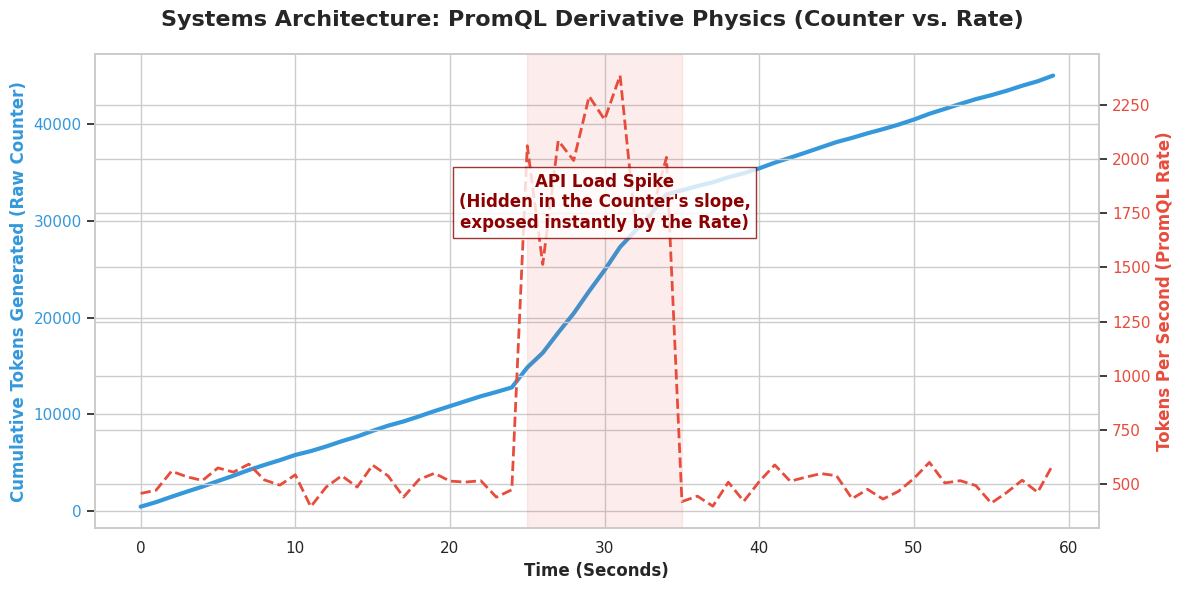

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for PromQL Calculus
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.suptitle("Systems Architecture: PromQL Derivative Physics (Counter vs. Rate)", fontsize=16, fontweight='bold')

# Simulate Time Series Data (60 seconds)
time_secs = np.arange(0, 60, 1)

# Simulate wildly fluctuating Tokens Per Second (The hidden reality)
# Baseline ~500 TPS, with a massive spike around second 30
true_tps = np.random.normal(500, 50, size=60)
true_tps[25:35] += np.random.normal(1500, 200, size=10) # Heavy API load spike

# The Counter tracks cumulative sum
cumulative_tokens = np.cumsum(true_tps)

# Plot 1: The Raw Counter (Left Y-Axis)
color1 = '#3498db'
ax1.set_xlabel('Time (Seconds)', fontweight='bold')
ax1.set_ylabel('Cumulative Tokens Generated (Raw Counter)', color=color1, fontweight='bold')
ax1.plot(time_secs, cumulative_tokens, color=color1, linewidth=3, label='llm_tokens_generated_total')
ax1.tick_params(axis='y', labelcolor=color1)

# Plot 2: The PromQL Rate / Derivative (Right Y-Axis)
ax2 = ax1.twinx()  
color2 = '#e74c3c'
ax2.set_ylabel('Tokens Per Second (PromQL Rate)', color=color2, fontweight='bold')

# The PromQL rate() function mathematically recovers the hidden TPS by taking the derivative
# rate(X) = (X_t - X_t-1) / 1s
calculated_rate = np.diff(cumulative_tokens, prepend=0)
ax2.plot(time_secs, calculated_rate, color=color2, linewidth=2, linestyle='--', label='rate(llm_tokens_generated_total[5s])')
ax2.tick_params(axis='y', labelcolor=color2)

# Highlight the Load Spike
ax2.axvspan(25, 35, color='#e74c3c', alpha=0.1)
ax2.text(30, 1800, "API Load Spike\n(Hidden in the Counter's slope,\nexposed instantly by the Rate)", 
         ha='center', va='center', fontweight='bold', color='darkred',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='darkred'))

fig.tight_layout()
plt.show()

*(Insight: The blue line is the raw data exposed by the Python container. It looks like a smooth upward slope. The red dashed line is what Prometheus calculates. The PromQL derivative mathematically exposes the violent, hidden $2000\text{ TPS}$ spike that occurred at $t=30$, allowing MLOps engineers to configure auto-scaling triggers.)*

## Real-World Use Case or Analogy:

Think of Prometheus Metric Scraping like **The Dashboard of a Formula 1 Race Car**:

* **Standard Logging (The Mechanic's Logbook):** Writing unstructured text logs is like having the driver manually write down *"The engine feels hot"* in a notebook every time they complete a lap. It is slow, qualitative, and by the time the pit crew reads the notebook, the engine has already exploded.
* **Prometheus (The F1 Telemetry Array):** The car is embedded with hundreds of sensors calculating exact numerical vectors: Oil Pressure (**Gauge**), Total Fuel Consumed (**Counter**), and Tire Temperature Distributions (**Histogram**).
* The car does not waste engine horsepower actively texting these numbers to the pit crew. It simply loads them into a localized circuit board.
* The Pit Crew's radio tower (**The Prometheus Server**) actively sweeps the car's circuit board every 10 milliseconds, *pulling* the numerical data over the airwaves.
* By applying continuous calculus (`rate()`) to the Total Fuel Consumed counter, the engineers instantly know exactly how much fuel is being burned per second, allowing them to adjust the engine mapping wirelessly before the driver even realizes there is an anomaly.